In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

   ---------------------------------------- 0.0/4.6 MB ? eta -:--:--
   ---------------------------------------- 4.6/4.6 MB 92.1 MB/s  0:00:00
   ---------------------------------------- 0.0/17.8 MB ? eta -:--:--
   -- ------------------------------------- 1.0/17.8 MB ? eta -:--:--
   ---- ----------------------------------- 2.1/17.8 MB 6.5 MB/s eta 0:00:03
   ------- -------------------------------- 3.1/17.8 MB 5.3 MB/s eta 0:00:03
   ------- -------------------------------- 3.1/17.8 MB 5.3 MB/s eta 0:00:03
   --------- ------------------------------ 4.2/17.8 MB 4.6 MB/s eta 0:00:03
   ----------- ---------------------------- 5.2/17.8 MB 4.4 MB/s eta 0:00:03
   ---------------- ----------------------- 7.3/17.8 MB 5.0 MB/s eta 0:00:03
   ---------------- ----------------------- 7.3/17.8 MB 5.0 MB/s eta 0:00:03
   ------------------ --------------------- 8.4/17.8 MB 4.8 MB/s eta 0:00:02
   ------------------ --------------------- 8.4/17.8 MB 4.8 MB/s eta 0:00:02
   ------------------ --


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 49.2 MB/s eta 0:00:01
   -------- ------------------------------- 2.1/9.5 MB 6.2 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.5 MB 6.2 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.5 MB 6.2 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 3.4 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 3.4 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 3.1 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 3.1 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 3.1 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 3.1 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 3.1 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.5 MB 2.2 MB/s eta 0:00:02
   ---------------


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136895 sha256=28d7e78b0593e5bc399b53b3c1c1447e4386d713fd816fd2ec92c53748b44261
  Stored in directory: c:\users\admin\appdata\local\packages\pythonsoftwarefoundation.python.3.11_qbz5n2kfra8p0\localcache\local\pip\cache\wheels\b1\7a\33\9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'pylatexenc' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pylatexenc'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.



In [2]:
def quantum_random_bit():
    """Generate a single random bit using a quantum measurement.
    Prepares |+> = (1/sqrt(2))(|0> + |1>) and measures it."""
    qc = QuantumCircuit(1, 1)
    qc.h(0)          # Apply Hadamard to |0> to get |+>
    qc.measure(0, 0)
    
    simulator = BasicSimulator()
    transpiled = transpile(qc, simulator)
    result = simulator.run(transpiled, shots=1).result()
    counts = result.get_counts()
    measured_bit = int(list(counts.keys())[0])
    return measured_bit

def quantum_random_bits(n):
    """Generate n random bits using quantum measurements."""
    return [quantum_random_bit() for _ in range(n)]

# Test the quantum random number generator
print("Generating 10 quantum random bits:")
test_bits = quantum_random_bits(10)
print(test_bits)

Generating 10 quantum random bits:
[1, 0, 0, 1, 1, 1, 1, 1, 0, 0]


In [19]:
NUM_QUBITS = 100  # Number of qubits Alice will send to Bob

print(f"BB84 Protocol Simulation (No Attacker)")
print(f"Number of qubits: {NUM_QUBITS}")

BB84 Protocol Simulation (No Attacker)
Number of qubits: 100


In [18]:
print("ALICE: Generating random bits and bases...")
alice_bits = quantum_random_bits(NUM_QUBITS)
alice_bases = quantum_random_bits(NUM_QUBITS)  # 0 = standard, 1 = diagonal

print(f"Alice's bits  (first 20): {alice_bits[:20]}")
print(f"Alice's bases (first 20): {alice_bases[:20]}")
print(f"(0 = standard basis, 1 = diagonal basis)")

ALICE: Generating random bits and bases...
Alice's bits  (first 20): [1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0]
Alice's bases (first 20): [1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0]
(0 = standard basis, 1 = diagonal basis)


ALICE: Encoding qubits...

Example: Alice's qubit 0 circuit (bit=1, basis=standard):


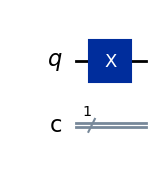

In [6]:
def alice_encode_qubits(bits, bases):
    """Alice encodes her bits into qubits using her chosen bases.
    Returns a list of QuantumCircuits, one per qubit."""
    encoded_qubits = []
    for i in range(len(bits)):
        qc = QuantumCircuit(1, 1)
        
        # Encode the bit value
        if bits[i] == 1:
            qc.x(0)  # Flip to |1>
        
        # Apply basis encoding
        if bases[i] == 1:
            qc.h(0)  # Switch to diagonal basis: |0>->|+>, |1>->|->
        
        encoded_qubits.append(qc)
    return encoded_qubits

print("ALICE: Encoding qubits...")
alice_qubits = alice_encode_qubits(alice_bits, alice_bases)

# Show an example circuit
print("\nExample: Alice's qubit 0 circuit (bit={}, basis={}):".format(
    alice_bits[0], 'diagonal' if alice_bases[0] == 1 else 'standard'))
alice_qubits[0].draw('mpl')

In [7]:
def bob_measure_qubits(qubits, bob_bases):
    """Bob measures each qubit in his randomly chosen basis.
    Returns the list of measured bits."""
    bob_results = []
    simulator = BasicSimulator()
    
    for i in range(len(qubits)):
        qc = qubits[i].copy()
        
        # If Bob chose the diagonal basis, apply H before measuring
        if bob_bases[i] == 1:
            qc.h(0)
        
        qc.measure(0, 0)
        
        transpiled = transpile(qc, simulator)
        result = simulator.run(transpiled, shots=1).result()
        counts = result.get_counts()
        measured_bit = int(list(counts.keys())[0])
        bob_results.append(measured_bit)
    
    return bob_results

print("BOB: Choosing random measurement bases...")
bob_bases = quantum_random_bits(NUM_QUBITS)  # 0 = standard, 1 = diagonal

print("BOB: Measuring qubits...")
bob_results = bob_measure_qubits(alice_qubits, bob_bases)

print(f"Bob's bases   (first 20): {bob_bases[:20]}")
print(f"Bob's results (first 20): {bob_results[:20]}")

BOB: Choosing random measurement bases...
BOB: Measuring qubits...
Bob's bases   (first 20): [0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0]
Bob's results (first 20): [1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1]


In [8]:
def sift_keys(alice_bits, alice_bases, bob_results, bob_bases):
    """Keep only bits where Alice and Bob used the same basis."""
    alice_key = []
    bob_key = []
    matching_indices = []
    
    for i in range(len(alice_bits)):
        if alice_bases[i] == bob_bases[i]:  # Same basis
            alice_key.append(alice_bits[i])
            bob_key.append(bob_results[i])
            matching_indices.append(i)
    
    return alice_key, bob_key, matching_indices

print("PUBLIC DISCUSSION: Comparing bases...")
alice_key, bob_key, matching_indices = sift_keys(alice_bits, alice_bases, bob_results, bob_bases)

print(f"\nTotal qubits sent: {NUM_QUBITS}")
print(f"Matching bases:    {len(matching_indices)} ({100*len(matching_indices)/NUM_QUBITS:.1f}%)")
print(f"\nAlice's sifted key (first 20): {alice_key[:20]}")
print(f"Bob's sifted key   (first 20): {bob_key[:20]}")

PUBLIC DISCUSSION: Comparing bases...

Total qubits sent: 100
Matching bases:    58 (58.0%)

Alice's sifted key (first 20): [1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1]
Bob's sifted key   (first 20): [1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1]


In [14]:
def verify_and_extract_key(alice_key, bob_key, sample_fraction=0.5):
    """Compare a subset of the sifted key to check for errors.
    Returns the final key (from the uncompared bits) and the error rate."""
    n = len(alice_key)
    sample_size = max(1, int(n * sample_fraction))
    
    # Use the first sample_size bits for verification (publicly compared)
    sample_alice = alice_key[:sample_size]
    sample_bob = bob_key[:sample_size]
    
    # Count errors in the sample
    errors = sum(a != b for a, b in zip(sample_alice, sample_bob))
    error_rate = errors / sample_size if sample_size > 0 else 0
    
    # The remaining bits form the final key
    final_key_alice = alice_key[sample_size:]
    final_key_bob = bob_key[sample_size:]
    
    return final_key_alice, final_key_bob, errors, error_rate, sample_size

print("VERIFICATION: Comparing a subset of the sifted key...")
final_key_alice, final_key_bob, errors, error_rate, sample_size = verify_and_extract_key(alice_key, bob_key)

print(f"\nSample size for verification: {sample_size}")
print(f"Errors found: {errors}")
print(f"Error rate: {error_rate:.4f} ({error_rate*100:.2f}%)")

# Detection threshold: any error rate above 0 suggests an attacker
THRESHOLD = 0.1  # 10% error rate threshold
if error_rate > THRESHOLD:
    print(f"\n ERROR RATE EXCEEDS THRESHOLD ({THRESHOLD*100}%)!")
    print("    POSSIBLE EAVESDROPPER DETECTED — Key is compromised!")
else:
    print(f"\nError rate is below threshold ({THRESHOLD*100}%).")
    print("No eavesdropper detected — Key is secure.")

VERIFICATION: Comparing a subset of the sifted key...

Sample size for verification: 29
Errors found: 0
Error rate: 0.0000 (0.00%)

Error rate is below threshold (10.0%).
No eavesdropper detected — Key is secure.


In [16]:
print("FINAL RESULTS:")
print(f"Original qubits sent:       {NUM_QUBITS}")
print(f"Sifted key length:          {len(alice_key)}")
print(f"Bits used for verification: {sample_size}")
print(f"Final key length:           {len(final_key_alice)}")
print(f"\nAlice's final key: {final_key_alice}")
print(f"Bob's final key:   {final_key_bob}")

# Confirm they match
keys_match = final_key_alice == final_key_bob
print(f"\nKeys match: {keys_match}")

if keys_match:
    print("\nSUCCESS: Alice and Bob have established a shared secret key!")
    key_string = ''.join(str(b) for b in final_key_alice)
    print(f"Shared key (binary): {key_string}")
else:
    print("\nFAILURE: Keys do not match (this should not happen without an attacker).")

FINAL RESULTS:
Original qubits sent:       100
Sifted key length:          58
Bits used for verification: 29
Final key length:           29

Alice's final key: [1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0]
Bob's final key:   [1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0]

Keys match: True

SUCCESS: Alice and Bob have established a shared secret key!
Shared key (binary): 10100100011100100100010100010


In [17]:
if keys_match and len(final_key_alice) > 0:
    # Convert a short message to binary
    message = "Hi"  # Keep it short so it fits in the key
    msg_bits = []
    for char in message:
        bits = format(ord(char), '08b')
        msg_bits.extend([int(b) for b in bits])
    
    # Truncate key to message length (or vice versa)
    usable_length = min(len(msg_bits), len(final_key_alice))
    msg_bits = msg_bits[:usable_length]
    key_bits = final_key_alice[:usable_length]
    
    # Encrypt: XOR message with key
    encrypted = [m ^ k for m, k in zip(msg_bits, key_bits)]
    
    # Decrypt: XOR ciphertext with key
    decrypted = [e ^ k for e, k in zip(encrypted, key_bits)]
    
    print("ONE-TIME PAD DEMONSTRATION:")
    print(f"Message bits:   {msg_bits}")
    print(f"Key bits:       {key_bits}")
    print(f"Encrypted bits: {encrypted}")
    print(f"Decrypted bits: {decrypted}")
    print(f"\nOriginal message recovered: {msg_bits == decrypted}")
else:
    print("Key too short or mismatched — skipping one-time pad demo.")

ONE-TIME PAD DEMONSTRATION:
Message bits:   [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1]
Key bits:       [1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0]
Encrypted bits: [1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1]
Decrypted bits: [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1]

Original message recovered: True
